# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

#### **Answer:** The dataset collected is related to 17 campaigns between May 2008 and November 2010.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

In [2]:
df_full = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



#### 3.1 Validate dataset size


In [4]:
df_full.shape

(41188, 21)

**Interpretation:** The dataset have `41,188` rows and `21` columns


#### 3.2 Check for NaNs

In [5]:
df_full.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Interpretation:** From above output, I can conclude that no nulls value exist in the dataset.

#### 3.3 Validate each column value

I will confirm that each value in dataset is the same as the variable definition from above. Also, I will verify each column value to check for missing data or inconsistencies.

In [6]:
# Print unique values for each column
def print_cols_value(df, cols):
    for col in cols:
        print(f"{col}: {df[col].unique()}")  # Print first 10 unique values for each categorical column

In [7]:
print_cols_value(df_full, df_full.columns)

age: [56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
job: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital: ['married' 'single' 'divorced' 'unknown']
education: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default: ['no' 'unknown' 'yes']
housing: ['no' 'yes' 'unknown']
loan: ['no' 'yes' 'unknown']
contact: ['telephone' 'cellular']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']
duration: [ 261  149  226 ... 1246 1556 1868]
campaign: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43

**Interpretation:** The dataset contains the value `unknown` in multiple colummns. The columns are `['job', 'marital', 'education', 'default', 'housing', 'loan']`.


#### 3.4 Handle unknown values

For this step, I will check how many unknown are for each column. Based on the results I will decide what to do with each value.

In [8]:
unknown_counts = {}
# loop through each column
for col in df_full.columns:
    unknown = (df_full[col] == 'unknown').sum()
    if unknown > 0:
        # append columns name as key, and total unknown as value
        unknown_counts[col] = (df_full[col] == 'unknown').sum()

# add columns names
result_df = pd.DataFrame(list(unknown_counts.items()), columns=['Column', 'Unknown_Count']).sort_values('Unknown_Count', ascending=False)

# calculate the percentage of unknown by column
result_df['Unknown (%)'] = (result_df['Unknown_Count'] / df_full.shape[0] * 100).round(2)
result_df

,Column,Unknown_Count,Unknown (%)
3,default,8597,20.87
2,education,1731,4.20
4,housing,990,2.40
5,loan,990,2.40
0,job,330,0.80
1,marital,80,0.19


**Interpretation:** We have 6 column with `unknown` values. The `default` column have the highest amount of `unknown` values with `20.87%`. The `education` column has significantly less amount of `unknown` with `4.20%`. The column `housing` and `loan` both have `2.4%` of `unknown` values. The column `job` has `0.80%` of `unknown`, and `marital` have `0.19%` of `unknown` values.

The columns `education`, `housing`, `loan`, `job`, `marital` has less than `5%` of missing values, this is a low number of missing values, so I will keep the `unknown` value as its own category for each column. This approach will help identify if missing this information has any correlation with the target variable.

The amount of `unknown` values in the `default` column is `20.87%`, which is a significant portion of the dataset. I will explore the distribution of the `default` column to validate if I should drop all rows with `unknown` values or replace them with the most frequent value.


#### 3.4.1 Handle default column

The `default` column has `20.87%` of `unknown` values. First, I will validate the distribution of this column to decide if I should drop all rows with `unknown` values or replace them with the most frequent value.

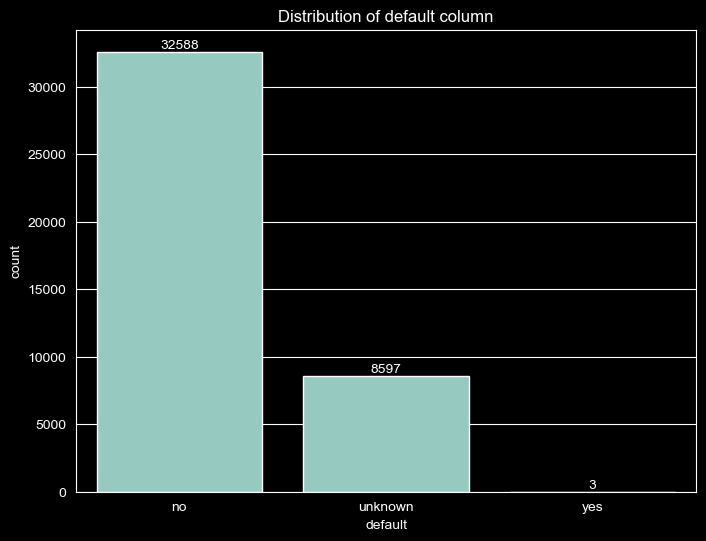

In [9]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x=df_full['default'])
ax.bar_label(ax.containers[0])
plt.title('Distribution of default column')
plt.show()

***Interpretation:*** The distribution of the `default` column shows that the majority of the values are `no` with a total of `32,568`, and a total of `3` `yes` . The amount of `unknown` values is `8,597`. There is low variance in the distribution of the `default` column, with a significant majority of `no` values and a small number of `yes` values.
This suggests that the `default` column may not be a helpful for our model predictions. Therefore, I will drop the default column from the dataset.

In [10]:
df_full = df_full.drop(columns=['default'])
df_full

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


***Interpretation:*** The `default` column has been dropped from the dataset as it does not provide significant information for model predictions.

#### 3.5 Verify datatype


In [11]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   housing         41188 non-null  object 
 5   loan            41188 non-null  object 
 6   contact         41188 non-null  object 
 7   month           41188 non-null  object 
 8   day_of_week     41188 non-null  object 
 9   duration        41188 non-null  int64  
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

***Interpretation:*** The following columns have `object` as the datatype, which is wrong: `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, `y`. All these column are categorical values, the datatype shoud be `category`.

#### 3.5.1 Update Datatype

In [12]:
categorical_columns = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

df_full[categorical_columns] = df_full[categorical_columns].astype('category')
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             41188 non-null  category
 2   marital         41188 non-null  category
 3   education       41188 non-null  category
 4   housing         41188 non-null  category
 5   loan            41188 non-null  category
 6   contact         41188 non-null  category
 7   month           41188 non-null  category
 8   day_of_week     41188 non-null  category
 9   duration        41188 non-null  int64   
 10  campaign        41188 non-null  int64   
 11  pdays           41188 non-null  int64   
 12  previous        41188 non-null  int64   
 13  poutcome        41188 non-null  category
 14  emp.var.rate    41188 non-null  float64 
 15  cons.price.idx  41188 non-null  float64 
 16  cons.conf.idx   41188 non-null  float64 
 17  euribor3m   

***Interpretation:*** All category columns were updated to use `category` as datatype

#### 3.6 Data analysis

This step I will create plots to help me understand the relationship between features and the target variable `y`.

#### 3.6.1 Target variable distribution

I would use a count plot to see the distribution of the target variable `y` to see if the dataset is balanced or imbalanced.

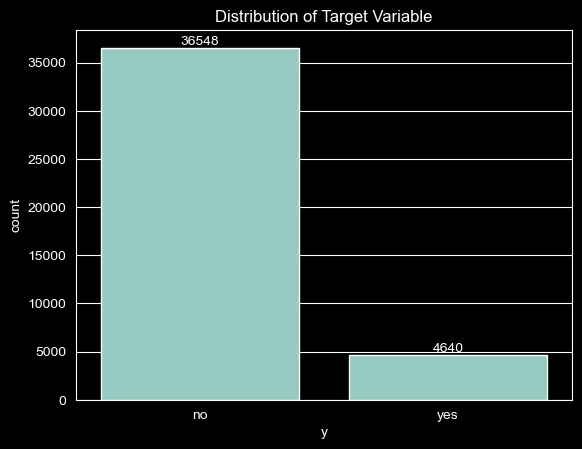

In [13]:
ax = sns.countplot(data=df_full, x='y')

ax.bar_label(ax.containers[0])
plt.title('Distribution of Target Variable')
plt.show()

***Interpretation:*** The target variable `y` is imbalanced with 36548 clients not subscribing to a term deposit and 4640 clients subscribing to a term deposit. This means that the model will need to be optimized to handle the imbalance.

#### 3.6.2 Age distribution

In this step, I will plot the distribution of age for clients who subscribed vs those who didn't.

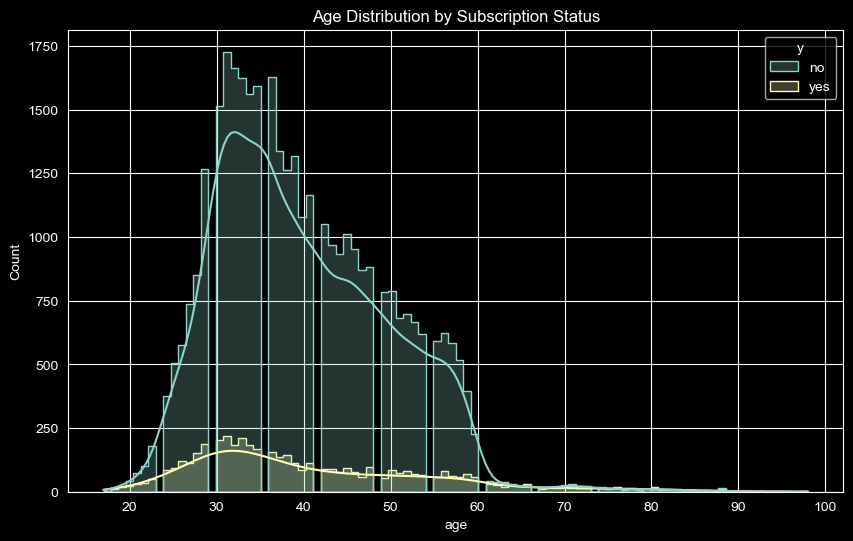

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_full, x='age', hue='y', kde=True, element="step")
plt.title('Age Distribution by Subscription Status')
plt.show()


***Interpretation:*** The age distribution plot shows

#### 3.6.3 Correlation heatmap for numeric features

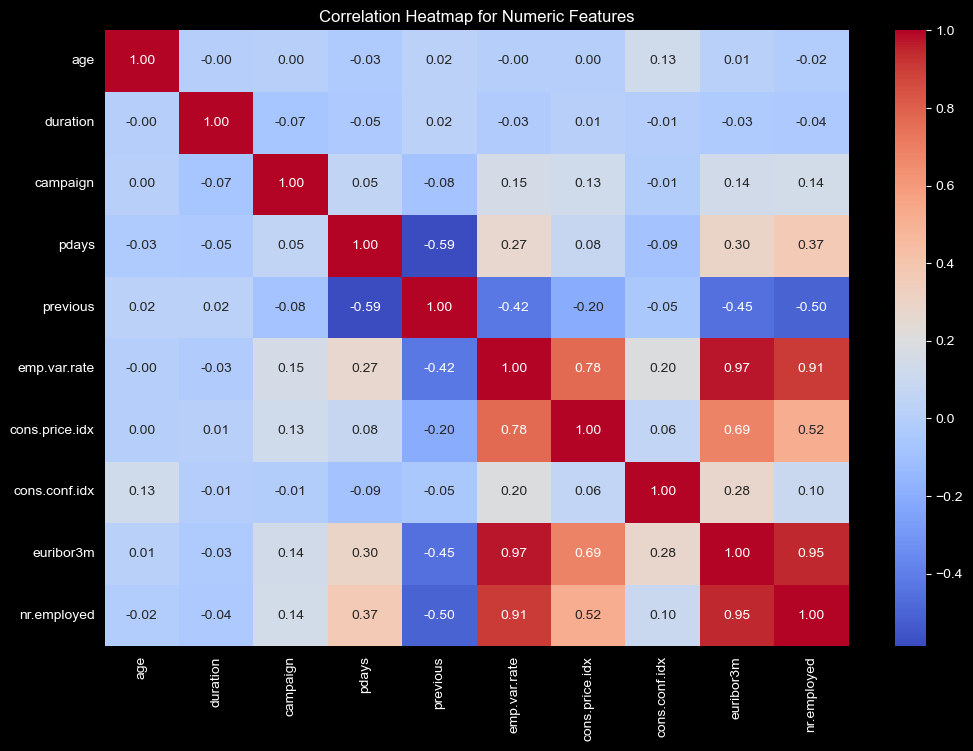

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_full.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for Numeric Features')
plt.show()

***Interpretation:*** The correlation heatmap shows multiple positive correlations between certain features, indicating that these features may be useful in predicting the target variable. A high correlation between the `euriborn3m` and `nr.employed` of `0.95`. The `euriborn3m` column has another correlation with `emp.var.rate` with `0.97`, and `emp.var.rate` also have a correlation with `cons.price.idx` with `0.78`. These three columns positively relates each other indicating a multicollinearity, this could be a issue because it could introduce redundant information. I will consider dropping some of these features or combine them.

A strong negative correlation exist between `pdays` and `previous` with `-0.59`. This makes sense because `pdays` is the number of days since last contact while `previous` is the number of contacts before campaing. The column `previous` has negative correlation with `emp.var.rate` with `-0.42`, and `nr.employed` with `nr.employed`.

The column `age` shows eak correlation with all other column, suggesting it provided independen information. Another weak correlation exist between `campaing` and `emp.var.rate`, `eurobem`, and `nr.employed` with `0.14` and `0.15`.

The column `duration` shows no correlation with other features, but in the data descripition, it is mentioned that the duration of the last contact is important for the outcome. This could be a potential feature to consider.


#### 3.6.4 Job vs Subscription

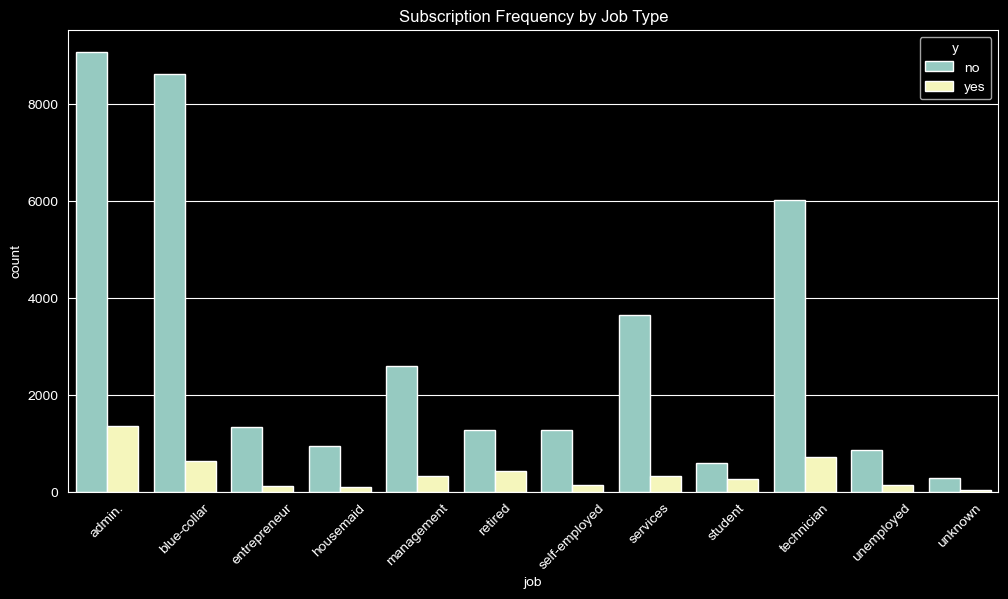

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_full, x='job', hue='y')
plt.xticks(rotation=45)
plt.title('Subscription Frequency by Job Type')
plt.show()

***Interpretation:*** The subscription frequency by job type shows that the most common job type for clients who subscribed are `admin`, `blue-collar`, and `technition`, however these clients represents the largest group of the dataset because they also have the most rejection (`no`), this means they have the lowest convertion rate.

The `students` and `retired` clients represents a small number of the dataset, however, the success looks like they have a higher chance of subscribing compared to the other job types.

Also, I can confirm there is data imbalance. There is a significant difference in the number of clients who subscribed (`yes`) and those who did not (`no`).


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Objective

The goal is to build and compare multiple classification models to predict whether a client will subscribe to a term deposit after a telemarketing campaign. The classification models to compare will be Logistic Regression, K Nearest Neighbors, Decision Treeds, and Support Vector Machines to predict the target variable y. The models will be optimized to identify the features of clients who are most likely to subscribe.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### 5.1 Filter by bank features

From the input variable table from Problem 3, the bank features are: `age`, `job`, `marital`, `education`, `housing`, `loan`.

First, I will encode the categorical features ( `job`, `marital`, `housing`, `loan` and scale numerical feature (`age`).

Then, I will encode the target variable `y`.

In [17]:
bank_features = ['age', 'job', 'marital', 'education', 'housing', 'loan', 'y']

df_bank = df_full[bank_features].copy()
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        41188 non-null  int64   
 1   job        41188 non-null  category
 2   marital    41188 non-null  category
 3   education  41188 non-null  category
 4   housing    41188 non-null  category
 5   loan       41188 non-null  category
 6   y          41188 non-null  category
dtypes: category(6), int64(1)
memory usage: 564.6 KB


***Interpretation:*** A new dataframe `df_bank` was created with only the bank features and target variable `y`. The dataframe has 4521 rows and 7 columns.

#### 5.2 Encode target variable `y`

The values of `y` are `yes` and `no`. I will transform the options to numeric using `yes = 1` and `no = 0`.

In [18]:
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
df_bank

,age,job,marital,education,housing,loan,y
0,56,housemaid,married,basic.4y,no,no,0
1,57,services,married,high.school,no,no,0
2,37,services,married,high.school,yes,no,0
3,40,admin.,married,basic.6y,no,no,0
4,56,services,married,high.school,no,yes,0
...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,1
41184,46,blue-collar,married,professional.course,no,no,0
41185,56,retired,married,university.degree,yes,no,0
41186,44,technician,married,professional.course,no,no,1


***Interpretation:*** The target variable `y` was encoded with `yes = 1` and `no = 0`.

#### 5.3 Encode input features

The categorical features needs encoding, features like: `job`, `marital`, `education`, `housing`, `loan` will be encode using One-Hot encoding. Numeric feature like `age` will be sacaled using `StandardScaler`.

In [19]:
# Categorical and numerical columns
cat_features = ['job', 'marital', 'education', 'housing', 'loan']
num_features = ['age']
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, drop='first') ,cat_features),
        ('scaler', StandardScaler() ,num_features)
    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('onehot',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['job', 'marital', 'education', 'housing',
                                  'loan']),
                                ('scaler', StandardScaler(), ['age'])])

***Interpretation:*** A preprocessor was created to manage column transformation. The categorial columns `'job', 'marital', 'education', 'housing', 'loan'` were encoded using One-Hot encoding method, and the `age` using StandardScaler.

#### 5.4 Separate feature and target

In this step, I will split the bank feature (`X`) from the target variable (`y`).

In [20]:
X = df_bank.drop(columns=['y'])
y = df_bank['y']
X.shape, y.shape

((41188, 6), (41188,))

***Interpretation:*** The dataset was split into features (`X`) and target (`y`). The shape of the feature matrix is (41188, 6) and the target vector is (41188,).

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

#### 7.1 DummyClassifier

For a baseline model I will use a DummyClassifier. For this dummy classifier I will use the `strategy` = `most_frequent`, this will predict the most frequent class in dataset. In this case, the data is imbalance with `88%` of `no`, therefore the DummyClassifier will predict `no` always.

In [22]:
# dummy_classifier = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

pipeline_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
]).fit(X_train, y_train)

baseline_train_acc = pipeline_dummy.score(X_train, y_train)
baseline_test_acc = pipeline_dummy.score(X_test, y_test)

print(f'Baseline Train Accuracy: {baseline_train_acc:.4f}')
print(f'Baseline Test Accuracy: {baseline_test_acc:.4f}')

Baseline Train Accuracy: 0.8876
Baseline Test Accuracy: 0.8865


***Interpretation:*** The baseline model using `DummyClassifier` with `most_frequent` strategy achieved a train accuracy of `0.8876` and a test accuracy of `0.8865`.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [23]:
pipeline_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression())
]).fit(X_train,y_train)

pipeline_logistic.named_steps['logreg'].coef_

array([[-0.44697491, -0.39108364, -0.22503861, -0.18663699,  0.75214016,
        -0.26666568, -0.3271962 ,  1.14564685, -0.1317322 ,  0.23854372,
        -0.27574767,  0.08340827,  0.38064177,  0.075278  , -0.03953923,
        -0.09758478,  0.01051353,  0.0884034 ,  0.1083352 ,  0.28916349,
         0.17263813,  0.04535993,  0.05836303,  0.04535993, -0.03177612,
         0.1092961 ]])

***Interpretation:*** A logistic regression model with default setting was build. Positive coefficients indicate that an increase in the corresponding feature is associated with an increase in the log-odds of the target variable being 1, while negative coefficients indicate the opposite.

### Problem 9: Score the Model

What is the accuracy of your model?

In [24]:
logistic_reg_train_acc = pipeline_logistic.score(X_train, y_train)
logistic_reg_test_acc = pipeline_logistic.score(X_test, y_test)

print(f'Logistic Regression Train Accuracy: {logistic_reg_train_acc:.4f}')
print(f'Logistic Regression Test Accuracy: {logistic_reg_test_acc:.4f}')

Logistic Regression Train Accuracy: 0.8876
Logistic Regression Test Accuracy: 0.8865


***Interpretation:*** The logistic regression model with default settings achieved a training accuracy of `0.8876` and a test accuracy of `0.8865`. The score was exactly the same as the DummyClassifier, this means the logistic regression model is not performing better than a simple baseline model. This could indicate that the features used are not informative enough to distinguish between the classes, the dataset imbalance is affecting the model, or that the model is not complex enough to capture the underlying patterns in the data. Further analysis and feature engineering might be necessary to improve the model's performance.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

#### 10.1 Reusable Training method

I will create a reusable method to train multiple models at the same time, which will allow us to compare their performance more easily. The method will take as input a list of models and return a dataframe with the results of the training process.

In [25]:

def train_models(models_list):
    # array to append results
    results =[]

    for name, model in models_list.items():

        # start time counter
        start_time = time.time()

        # pipeline to fit all models
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ]).fit(X_train, y_train)
        # duration
        duration = time.time() - start_time

        # append model result
        results.append({
            'Model': name,
            'Train Time (s)': duration,
            'Train Accuracy': pipeline.score(X_train, y_train),
            'Test Accuracy': pipeline.score(X_test, y_test),
            'ROC-AUC': roc_auc_score(y_test, pipeline.predict(X_test)),
            'f1': f1_score(y_test, pipeline.predict(X_test)),
            'recall': recall_score(y_test, pipeline.predict(X_test))
        })

    # show results as dataframe
    return pd.DataFrame(results)



***Interpretation:*** The method `train_models` is a reusable function that trains a list of models on a given dataset and returns a dataframe with the training results. It encapsulates the training process, timing, and evaluation of each model, making it easy to compare their performance.

#### 10.2 Train Default Model

In [26]:
# list of models to train
models_default = {
    'Dummy': DummyClassifier(),
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVC': SVC()
}

# show results as dataframe
df_results =  train_models(models_default)
df_results


,Model,Train Time (s),Train Accuracy,Test Accuracy,ROC-AUC,f1,recall
0,Dummy,0.031866,0.887557,0.886502,0.500000,0.000000,0.000000
1,Logistic Regression,0.063702,0.887557,0.886502,0.500000,0.000000,0.000000
2,KNN,0.023905,0.888923,0.873634,0.517456,0.092415,0.056684
3,Decision Tree,0.116347,0.911958,0.866594,0.522811,0.117269,0.078075
4,SVC,19.015329,0.888346,0.886744,0.503401,0.014784,0.007487


**Interpretation:** In this step, we tested 5 models and compared their performance metrics. The models trained were `DummyClassifier`, `LogisticRegression`, `KNeighborsClassifier`, `DecisionTreeClassifier`, and `SVC`. Comparing their performance, none of the models performed better than the DummyClassifier, the test accuracy for `DummyClassifier` was `0.8865`, the closest model was `SVC` with a test accuracy of `0.8867` but took `36.7 s` to train, which is not an improvement. The model needs to be improved.

The `ROC-AUC` value for all models are close to `0.50` which indicates that the models are not performing better than random guessing. This suggests that the models are not able to distinguish between the classes effectively.

For class imbalance, **F1** is a strong primary metric because it balances precision and recall.


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
- Adjust your performance metric

#### 11.1 Class Imbalance

In this dataset, the target variable is imbalanced, with a higher number of samples belonging to the `no` (`89%`) class compared to the `yes` (`11%`). This can lead to biased models that perform poorly on the minority class as confirmed on the previous step, where a `DummyClassifier` was the best model.

To address this issue, I will use the parameter `class_weight` = `balanced` for models `LogisticRegression`, `DecisionTreeClassifier`, and `SVC`. For `DummyClassifier` I will use `strategy='stratified'`. This will tell the model to pay more attention to `yes` class.

For `KNeighborsClassifier`, I will use `weights='distance'` to makes closer neighbors more influential in the classification process.

In [27]:
# list of models to train
models_balanced = {
    'Dummy': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(weights='distance'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'SVC': SVC(class_weight='balanced', random_state=42)
}

# show results as dataframe
df_results = train_models(models_balanced)
df_results


,Model,Train Time (s),Train Accuracy,Test Accuracy,ROC-AUC,f1,recall
0,Dummy,0.022090,0.800637,0.799466,0.495675,0.104121,0.102674
1,Logistic Regression,0.585120,0.616358,0.617019,0.589548,0.247196,0.554011
2,KNN,0.036569,0.907769,0.866837,0.525280,0.124501,0.083422
3,Decision Tree,0.066179,0.751502,0.659869,0.558694,0.222099,0.427807
4,SVC,24.656582,0.647071,0.631221,0.589632,0.248020,0.535829


***Interpretation:*** The accuracy dropped when using `class_weight='balance'`. The `Logistic Regression` model test accuracy dropped to `61.7%`,  The `DecisionTreeClassifier` model test accuracy dropped to `65.9%`, The `SVC` model test accuracy dropped to `63.1%` but it tokes longer time to train, more than `30 seconds`. The accuracy decrease is a good signal because the models are no longer predicting the majority class.

The `ROC-AUC` increase for all model (previous was `0.5`) which is an improvement from previous steps. The `Logistic Regression` model `ROC-AUC` increased to `0.589`, the `DecisionTreeClassifier` model `ROC-AUC` increased to `0.558`, the `SVC` model `ROC-AUC` increased to `0.589`.

The `recall` from `Logistic Regression` and `SVC` models are `0.554` and `0.536` respectively, this means these models are finding more than half of the subscribers.

The `KNeighborsClassifier` model was the only one with increase accuracy with `86.7%` it didn't use `class_weight` = `balance`, the `weight` was `distance` so this model is probably still biased towards the majority class.

#### 11.2 GridSearchCV

I will use GridSearchCV to tune the hyperparameters of the all models to improve performance.


#### 11.2.1 Define parameters

The following are the parameters that will be used to tuned each model.

In [28]:
# Takes more than 10 min to train
# param_grids = {
#     "KNN": {
#         "model__n_neighbors": [5, 11, 15, 25, 51],
#         "model__weights": ["uniform", "distance"]
#     },
#     "Logistic Regression": {
#         "model__C": [0.01, 0.1, 1.0, 10.0],
#         "model__class_weight": [None, "balanced"],
#         "model__penalty": ["l1", "l2"],
#         "model__solver": ["liblinear"],
#     },
#     "Decision Tree": {
#         "model__max_depth": [3, 5, 7, 10],
#         "model__min_samples_split": [2, 10, 30],
#         "model__min_samples_leaf": [1, 5, 10],
#         "model__class_weight": [None, "balanced"],
#     },
#     "SVC": {
#         "model__C": [0.1, 1.0, 5.0],
#         "model__gamma": ["scale", 0.1,],
#         "model__class_weight": [None, "balanced"]
#     }
# }

# Faster training time by reducing redundant time consuming checks
param_grids_fast = {
    "KNN": {
        "model__n_neighbors": [15, 25, 51],
        "model__weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear"],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 10],
        "model__min_samples_split": [10, 30],
        "model__class_weight": [None, "balanced"],
    },
    "SVC": {
        "model__C": [0.1, 1.0],
        "model__gamma": ["scale"],
        "model__class_weight": ["balanced"] # Focus only on balanced
    }
}

#### 11.2.2 Reusable function to use GridSearchCV


In [29]:
def train_grid_cv_models(models_list, params):
    # array to append results
    best_models = {}
    tuning_rows = []

    for name, model in models_list.items():

        # start time counter
        start_time = time.time()

        # pipeline to fit all models
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        grid = GridSearchCV(pipeline, params[name], cv=3, scoring='roc_auc', n_jobs=1).fit(X_train, y_train)

        # duration
        duration = time.time() - start_time
        best_models[name] = grid.best_estimator_

        # append model result
        tuning_rows.append({
            "model": f"Tuned {name}",
            "tuning_time_sec": duration,
            "best_roc_auc_cv": grid.best_score_,
            "best_params": grid.best_params_
        })


    # show results as dataframe
    df_grid_results = pd.DataFrame(tuning_rows).sort_values("best_roc_auc_cv", ascending=False)
    return df_grid_results, best_models


***Interpretation:*** The function `train_grid_cv_models` performs hyperparameter tuning for a list of models using GridSearchCV. It measures the tuning time for each model, records the best ROC AUC score and corresponding parameters, and returns a sorted dataframe of results along with the best models. This approach helps in identifying the most effective model configurations for the given dataset.

In [31]:
models_tuning = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(weights='distance'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'SVC': SVC(class_weight='balanced', random_state=42)
}

grid_results, best_models = train_grid_cv_models(models_tuning, param_grids_fast)


***Interpretation:*** The `train_grid_cv_models` was called with four models for hypertuning.

In [32]:
grid_results


,model,tuning_time_sec,best_roc_auc_cv,best_params
3,Tuned SVC,122.910922,0.631038,"{'model__C': 0.1, 'model__class_weight': 'bala..."
2,Tuned Decision Tree,1.329258,0.624846,"{'model__class_weight': None, 'model__max_dept..."
0,Tuned Logistic Regression,2.107845,0.622771,"{'model__C': 0.1, 'model__class_weight': 'bala..."
1,Tuned KNN,2.471256,0.618654,"{'model__n_neighbors': 51, 'model__weights': '..."


***Interpretation:*** The results of the hyperparameter tuning are presented in a sorted dataframe, showing the best models based on `ROC-AUC` scores. The best model was `SVC` with a `ROC-AUC` score of `0.631`, the best params were `{'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale'}` but took `122.9 seconds` to train.

In second place was `Decision Tree` with a `ROC-AUC` score of `0.625` with the following paras: `{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_split': 30}` and took `1.33 seconds` to train.

Logistic regression was third with a `ROC-AUC` score of `0.623` with the following params: `{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}` and took `2.11 seconds` to train.

The last places was for `KNN` with a `ROC-AUC` score of `0.619` with the following params: `{'model__n_neighbors': 51, 'model__weights': 'uniform'}` and took `2.47 seconds` to train.


In [185]:
best_models

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('onehot',
                                                   OneHotEncoder(drop='first',
                                                                 sparse_output=False),
                                                   ['job', 'marital',
                                                    'education', 'housing',
                                                    'loan']),
                                                  ('scaler', StandardScaler(),
                                                   ['age'])])),
                 ('model',
                  LogisticRegression(C=0.1, class_weight='balanced',
                                     random_state=42))]),
 'KNN': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('onehot',
                                                   OneHotEncoder(drop='first',
                              

***Interpretation:*** The `best_models` dictionary contains the best models for each of the four models that were hypertuned. The models are `SVC`, `Decision Tree`, `Logistic Regression`, and `KNN`.

For maximum prediction power: The bank should use the tuned `SVC` model with the following parameters: `{'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale'}`. This model achieved the highest `ROC-AUC` score of `0.631` and was the fastest to train with `122.9 seconds`.

If training time is a concern, the bank should consider using the tuned `Decision Tree` model with the following parameters: `{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_split': 30}`. This model achieved a `ROC-AUC` score of `0.625` and was the second fastest to train with `1.33 seconds`. This model provides almost identical performance, is much faster to train, and easier to explain.

##### Questions